In [2]:
import pandas as pd

df=pd.read_excel(r"C:\Users\Lenovo\Desktop\CLASSROOM\DA\projects\customer_segmentation\Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [7]:
df['CustomerID']=df['CustomerID'].astype(int)


In [8]:
df['total_price']=df['UnitPrice']*df['Quantity']

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


RFM TABLE

In [10]:
import datetime as dt

# reference date (latest date in dataset)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'CustomerID': 'count',
    'total_price': 'sum'
})

# rename columns
rfm.columns = ['recency', 'frequency', 'monetary']

rfm.head()

,recency,frequency,monetary
CustomerID,,,
12346,326,2,0.00
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


In [11]:


rfm.head()

,recency,frequency,monetary
CustomerID,,,
12346,326,2,0.00
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


In [12]:
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'], 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

In [13]:
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score
CustomerID,,,,,,
12346,326,2,0.00,1,1,1
12347,2,182,4310.00,5,5,5
12348,75,31,1797.24,2,3,4
12349,19,73,1757.55,4,4,4
12350,310,17,334.40,1,2,2


In [14]:
# Clean 6-segment RFM assignment using R, F, and M 
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    # Champions: bought recently, buy often, spend the most
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    # Loyal: buy often and spend well, maybe not most recent
    elif f >= 4 and m >= 3:
        return 'Loyal Customers'
    # New: bought very recently but low frequency
    elif r >= 4 and f <= 2:
        return 'New Customers'
    # At Risk: used to be good (high F/M) but haven't bought recently
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    # Lost: low on everything
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# the real numbers
print(rfm['segment'].value_counts())
print()

# revenue by segment
seg_rev = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
print(seg_rev)
print()

# % of revenue per segment
print((seg_rev / seg_rev.sum() * 100).round(1))

segment
Lost Customers     1070
Others             1070
Champions           946
Loyal Customers     679
New Customers       362
At Risk             245
Name: count, dtype: int64

segment
Champions          5525408.760
Loyal Customers    1245758.911
Others              703032.851
Lost Customers      394565.362
At Risk             238805.970
New Customers       192493.960
Name: monetary, dtype: float64

segment
Champions          66.6
Loyal Customers    15.0
Others              8.5
Lost Customers      4.8
At Risk             2.9
New Customers       2.3
Name: monetary, dtype: float64


In [15]:
#Which segment has most customers?
rfm['segment'].value_counts()

segment
Lost Customers     1070
Others             1070
Champions           946
Loyal Customers     679
New Customers       362
At Risk             245
Name: count, dtype: int64

Revenue is highly concentrated: Champions are 22% of customers but drive 66.6% of revenue.

In [16]:
#Which segment earns most money?
rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

segment
Champions          5525408.760
Loyal Customers    1245758.911
Others              703032.851
Lost Customers      394565.362
At Risk             238805.970
New Customers       192493.960
Name: monetary, dtype: float64

In [17]:
#. Average value per segment
rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)

segment
Champions          5840.812643
Loyal Customers    1834.696482
At Risk             974.718245
Others              657.040048
New Customers       531.751271
Lost Customers      368.752675
Name: monetary, dtype: float64

In [18]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4372 entries, 12346 to 18287
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   recency    4372 non-null   int64  
 1   frequency  4372 non-null   int64  
 2   monetary   4372 non-null   float64
 3   r_score    4372 non-null   int64  
 4   f_score    4372 non-null   int64  
 5   m_score    4372 non-null   int64  
 6   segment    4372 non-null   object 
dtypes: float64(1), int64(5), object(1)
memory usage: 273.2+ KB


In [19]:
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

In [20]:
rfm.dtypes

recency        int64
frequency      int64
monetary     float64
r_score        int64
f_score        int64
m_score        int64
segment       object
dtype: object

In [21]:
rfm.head()

,recency,frequency,monetary,r_score,f_score,m_score,segment
CustomerID,,,,,,,
12346,326,2,0.00,1,1,1,Lost Customers
12347,2,182,4310.00,5,5,5,Champions
12348,75,31,1797.24,2,3,4,At Risk
12349,19,73,1757.55,4,4,4,Champions
12350,310,17,334.40,1,2,2,Lost Customers


In [22]:
rfm['segment'].value_counts()

segment
Lost Customers     1070
Others             1070
Champions           946
Loyal Customers     679
New Customers       362
At Risk             245
Name: count, dtype: int64

The number of Lost customers is high fand that need to be improved

In [23]:
rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

segment
Champions          5525408.760
Loyal Customers    1245758.911
Others              703032.851
Lost Customers      394565.362
At Risk             238805.970
New Customers       192493.960
Name: monetary, dtype: float64

In [24]:
rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)

segment
Champions          5840.812643
Loyal Customers    1834.696482
At Risk             974.718245
Others              657.040048
New Customers       531.751271
Lost Customers      368.752675
Name: monetary, dtype: float64

Champions are extremely valuable customers contributing the highest revenue per user.

In [25]:
rfm.groupby('segment')['frequency'].mean()

segment
At Risk             42.085714
Champions          260.650106
Lost Customers      13.418692
Loyal Customers    130.266568
New Customers       15.320442
Others              38.867290
Name: frequency, dtype: float64

In [26]:
rfm.groupby('segment')['recency'].mean()

segment
At Risk            150.497959
Champions           12.093023
Lost Customers     212.000935
Loyal Customers     76.835052
New Customers       16.458564
Others              64.624299
Name: recency, dtype: float64

In [27]:
rfm.groupby('segment').agg({
    'monetary': ['count', 'sum', 'mean']
}).sort_values(('monetary', 'sum'), ascending=False)

monetary                          
                   count          sum         mean
segment                                           
Champions            946  5525408.760  5840.812643
Loyal Customers      679  1245758.911  1834.696482
Others              1070   703032.851   657.040048
Lost Customers      1070   394565.362   368.752675
At Risk              245   238805.970   974.718245
New Customers        362   192493.960   531.751271

The analysis revealed that Champions contribute the highest average revenue per customer (~₹9.3K), while Lost Customers contribute the least (~₹368). This indicates strong revenue concentration among high-value segments and highlights opportunities for re-engagement strategies for At-Risk and New customers.

Text(0.5, 1.0, 'Customers per Segment')

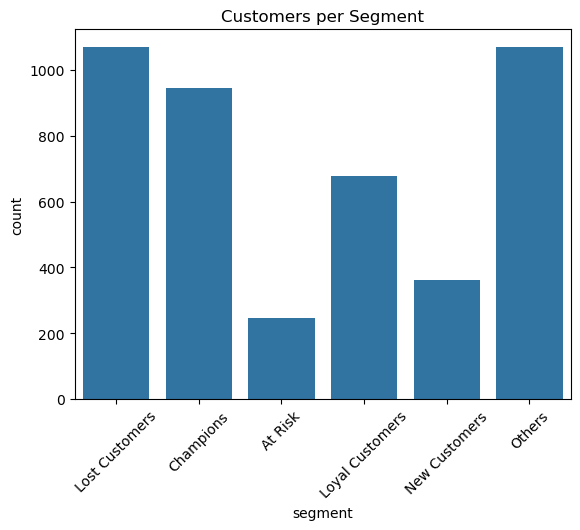

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=rfm, x='segment')
plt.xticks(rotation=45)
plt.title("Customers per Segment")

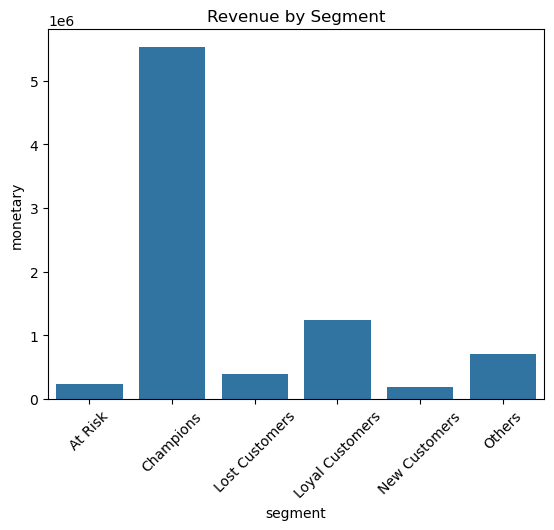

In [29]:
revenue = rfm.groupby('segment')['monetary'].sum().reset_index()
sns.barplot(data=revenue, x='segment', y='monetary')
plt.xticks(rotation=45)
plt.title("Revenue by Segment")
plt.show()

Although Lost Customers are high in number, they contribute very little revenue, whereas Champions and Loyal Customers are the most contributers.

In [37]:
rfm.reset_index().to_csv(
    r"C:\Users\Lenovo\Desktop\CLASSROOM\DA\projects\customer_segmentation\rfm_final.csv",
    index=False
)

In [39]:
df_out = rfm.reset_index() if rfm.index.name == 'CustomerID' else rfm.copy()
df_out['rf_score'] = df_out['r_score'].astype(str) + df_out['f_score'].astype(str)
df_out.to_csv(
    r"C:\Users\Lenovo\Desktop\CLASSROOM\DA\projects\customer_segmentation\rfm_final.csv",
    index=False
)
print("Written. Header check:")
print(open(r"C:\Users\Lenovo\Desktop\CLASSROOM\DA\projects\customer_segmentation\rfm_final.csv").readline())

Written. Header check:
CustomerID,recency,frequency,monetary,r_score,f_score,m_score,segment,rf_score



In [40]:
rfm=rfm.reset_index()

In [41]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       4372 non-null   int64  
 1   CustomerID  4372 non-null   int64  
 2   recency     4372 non-null   int64  
 3   frequency   4372 non-null   int64  
 4   monetary    4372 non-null   float64
 5   r_score     4372 non-null   int64  
 6   f_score     4372 non-null   int64  
 7   m_score     4372 non-null   int64  
 8   segment     4372 non-null   object 
dtypes: float64(1), int64(7), object(1)
memory usage: 307.5+ KB


## Key Findings
- **Champions**: 946 customers (22% of base) drive **66.6% of revenue**
- Revenue is highly concentrated — retaining Champions is the primary lever
- Lost + Others make up ~49% of customers but only ~13% of revenue


## 📅 Cohort Retention Analysis
Tracking how customer groups (by first-purchase month) retain over time.


In [44]:
# --- Cohort setup ---
import numpy as np

# work on a copy so we don't disturb the RFM work
coh = df[['CustomerID', 'InvoiceNo', 'InvoiceDate']].copy()

# the month of each individual transaction (e.g. 2010-12)
coh['order_month'] = coh['InvoiceDate'].dt.to_period('M')

# each customer's FIRST-ever purchase month = their cohort
coh['cohort_month'] = coh.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

coh.head()

,CustomerID,InvoiceNo,InvoiceDate,order_month,cohort_month
0,17850,536365,2010-12-01 08:26:00,2010-12,2010-12
1,17850,536365,2010-12-01 08:26:00,2010-12,2010-12
2,17850,536365,2010-12-01 08:26:00,2010-12,2010-12
3,17850,536365,2010-12-01 08:26:00,2010-12,2010-12
4,17850,536365,2010-12-01 08:26:00,2010-12,2010-12


In [45]:
# how many distinct cohorts (should be ~13: Dec 2010 through Dec 2011)
print(coh['cohort_month'].nunique())

# the cohort sizes (customers who first bought each month)
print(coh.groupby('cohort_month')['CustomerID'].nunique())

13
cohort_month
2010-12    948
2011-01    421
2011-02    380
2011-03    440
2011-04    299
2011-05    279
2011-06    235
2011-07    191
2011-08    167
2011-09    298
2011-10    352
2011-11    321
2011-12     41
Freq: M, Name: CustomerID, dtype: int64


In [46]:
# --- Cohort index: months since the customer's first purchase ---
# subtract cohort_month from order_month to get the offset in months
coh['cohort_index'] = (coh['order_month'] - coh['cohort_month']).apply(lambda x: x.n)

coh[['CustomerID', 'order_month', 'cohort_month', 'cohort_index']].head(10)

,CustomerID,order_month,cohort_month,cohort_index
0,17850,2010-12,2010-12,0
1,17850,2010-12,2010-12,0
2,17850,2010-12,2010-12,0
3,17850,2010-12,2010-12,0
4,17850,2010-12,2010-12,0
5,17850,2010-12,2010-12,0
6,17850,2010-12,2010-12,0
7,17850,2010-12,2010-12,0
8,17850,2010-12,2010-12,0
9,13047,2010-12,2010-12,0


In [47]:
print(coh['cohort_index'].min(), coh['cohort_index'].max())

0 12


In [52]:
# --- Build the retention grid ---
# count distinct customers per cohort per month-offset
cohort_data = coh.groupby(['cohort_month', 'cohort_index'])['CustomerID'].nunique().reset_index()

# pivot: cohorts as rows, month-offset as columns
cohort_counts = cohort_data.pivot(index='cohort_month',
                                  columns='cohort_index',
                                  values='CustomerID')

# retention % = each cell divided by that cohort's month-0 size
cohort_size = cohort_counts.iloc[:, 0]                 # the index-0 column = cohort's starting size
retention = cohort_counts.divide(cohort_size, axis=0)  # divide every column by that size

retention.round(3)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,1.0,0.382,0.334,0.387,0.360,0.397,0.380,0.354,0.354,0.395,0.373,0.50,0.274
2011-01,1.0,0.240,0.283,0.242,0.328,0.299,0.261,0.257,0.311,0.347,0.368,0.15,NaN
2011-02,1.0,0.247,0.192,0.279,0.268,0.247,0.255,0.282,0.258,0.313,0.092,NaN,NaN
2011-03,1.0,0.191,0.255,0.218,0.232,0.177,0.264,0.239,0.289,0.089,NaN,NaN,NaN
2011-04,1.0,0.227,0.221,0.211,0.207,0.237,0.231,0.261,0.084,NaN,NaN,NaN,NaN
2011-05,1.0,0.237,0.172,0.172,0.215,0.244,0.265,0.104,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.209,0.187,0.272,0.247,0.336,0.102,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.209,0.204,0.230,0.272,0.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.251,0.251,0.251,0.138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


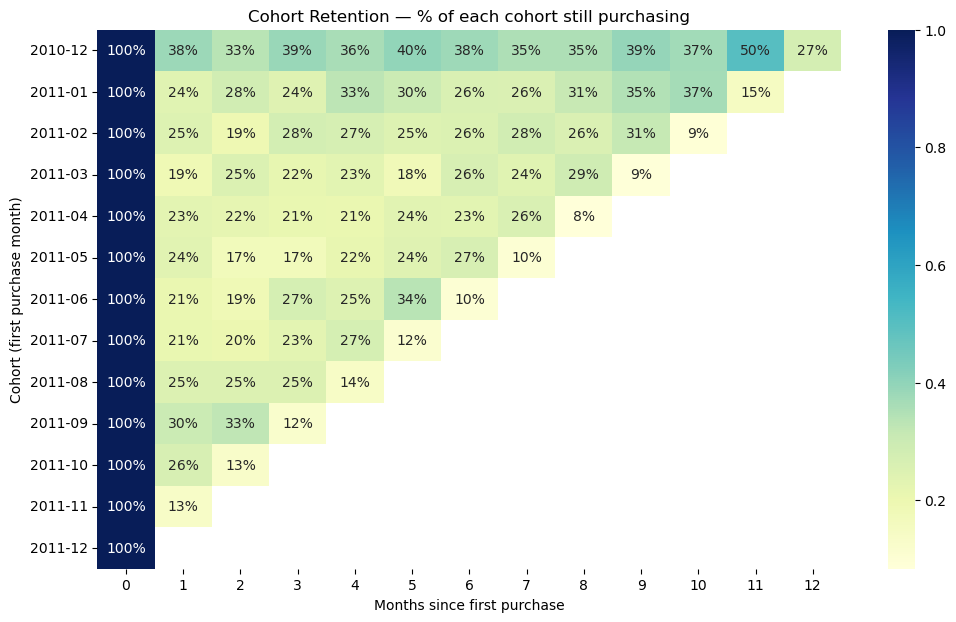

In [55]:
plt.figure(figsize=(12, 7))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Cohort Retention — % of each cohort still purchasing')
plt.ylabel('Cohort (first purchase month)')
plt.xlabel('Months since first purchase')
plt.savefig('cohort_retention.png', bbox_inches='tight')
plt.show()

### Cohort Retention — Key Findings
- **Sharp month-1 drop-off:** retention falls from 100% to ~25–38% after the first month — most customers don't make a second purchase. Early churn, not acquisition, is the core problem.
- **Survivors are durable:** cohorts stabilise around 20–30% after month 1, and the Dec 2010 cohort holds ~30–50% even a year out. Customers who make a second purchase tend to stay.
- **Actionable takeaway:** the highest-leverage intervention is a second-purchase nudge within the first 30 days of acquisition.
- *Note: the Dec 2010 cohort absorbs pre-existing active customers, so it over-retains relative to true new-customer cohorts.*

## 💡 Business Recommendations by Segment

Each segment maps to a specific action, a metric to measure success, and the business rationale.

| Segment | Action | Metric to Track | Rationale |
|---|---|---|---|
| **Champions** (22%, 66.6% rev) | VIP program, early access, referral incentives | Retention rate, referral conversion | Drive most of revenue — goal is retention, not extraction. Losing one hurts disproportionately. |
| **Loyal** (15.5%, 15% rev) | Upsell via bundles, cross-sell adjacent categories | Avg order value, cross-sell rate | Stable base — grow spend without risking the relationship. |
| **At Risk** (5.6%) | Time-sensitive win-back offer on past categories | 30-day reactivation rate | Used to be valuable but stopped buying. Still rescuable — drifting toward Lost. |
| **New** (8.3%) | Onboarding + second-purchase incentive | Second-purchase rate within 30 days | Ties to cohort finding: retention drops after month 1. Converting first-time buyers is the biggest lever. |
| **Lost** (24.5%) | Low-cost win-back email; don't over-invest | Reactivation rate (expected low) | Large but low-value. Cheap attempt only. |
| **Others** (24.5%) | Monitor; light engagement | Migration into At Risk or Loyal | No strong signal — watch which way they drift. |

**Key link:** the cohort analysis showed a sharp month-1 retention drop, so the highest-priority action is a **second-purchase incentive for New Customers** — attacking early churn at its source.

## 🧪 A/B Test Design — At-Risk Win-Back Campaign

To validate the At-Risk recommendation, I would run a controlled experiment rather than assume the campaign works.

**Hypothesis:** A time-sensitive discount offer to At-Risk customers will increase their 30-day reactivation rate versus no campaign.

**Setup:**
- Population: the 245 At-Risk customers
- Random 50/50 split: ~122 Control (no offer) vs ~123 Treatment (win-back offer)
- Random assignment ensures the two groups are comparable

**Success metric:** 30-day reactivation rate — % of each group making a purchase within 30 days.

**Decision rule:** if the Treatment group's reactivation rate is significantly higher than Control (p < 0.05), roll the offer out to all At-Risk customers. If not, the offer isn't effective and a different intervention is needed.

**Limitation:** 245 customers is a small sample, so only a sizable effect would reach significance. A real test would benefit from a longer window or a larger segment.